<a href="https://colab.research.google.com/github/LielUziahu/Stylophora-pistillata-FPs/blob/main/FIRe_ambient.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Statistical Test: Independent t-test


,Variable,HF Mean,HF Std,HF Count,NF Mean,NF Std,NF Count,P-value
0,Fm,11.308,4.375,39,8.600,1.424,6,0.143 (ns)


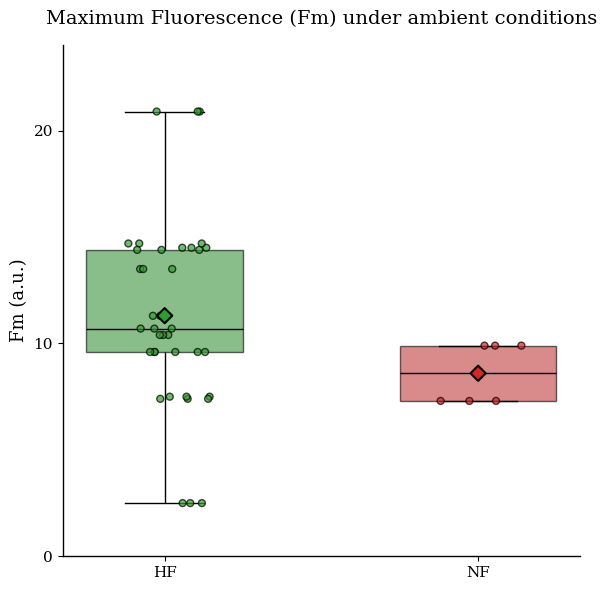


Statistical Test: Independent t-test


,Variable,HF Mean,HF Std,HF Count,NF Mean,NF Std,NF Count,P-value
0,fv_fm,0.377,0.110,39,0.397,0.072,6,0.676 (ns)


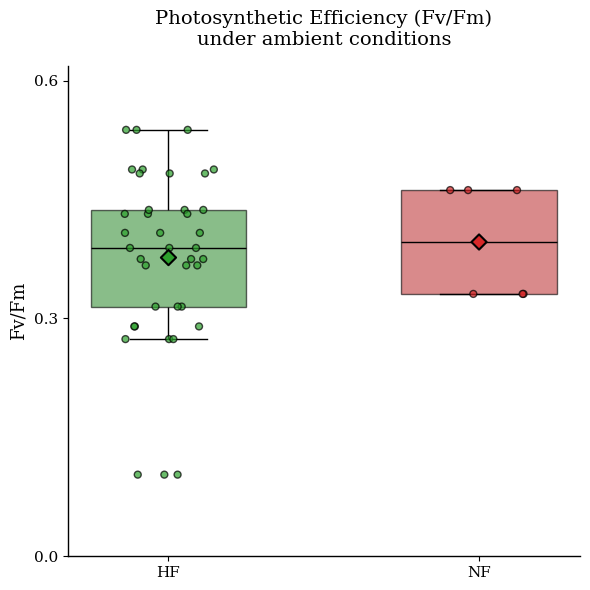


Statistical Test: Independent t-test


,Variable,HF Mean,HF Std,HF Count,NF Mean,NF Std,NF Count,P-value
0,Pmax.e.s,131.908,81.649,39,77.300,10.078,6,0.112 (ns)


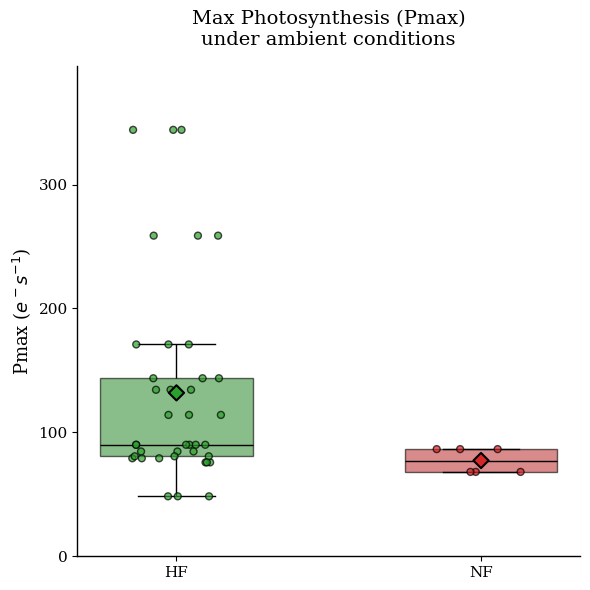


Statistical Test: Independent t-test


,Variable,HF Mean,HF Std,HF Count,NF Mean,NF Std,NF Count,P-value
0,p,0.255,0.262,39,0.195,0.214,6,0.594 (ns)


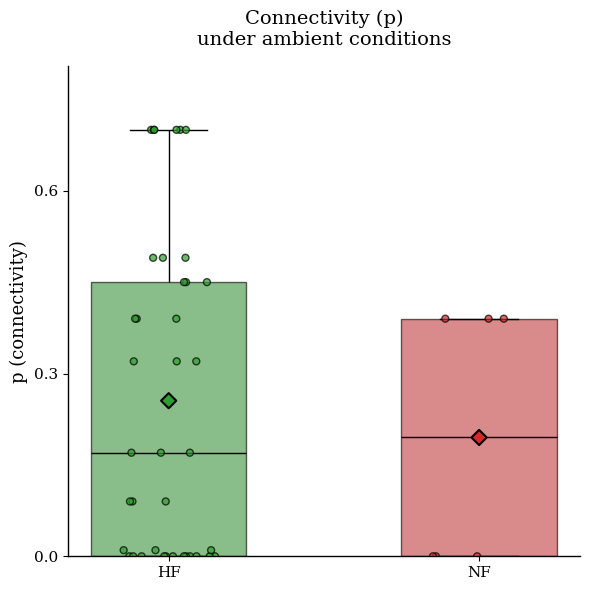


Statistical Test: Independent t-test


,Variable,HF Mean,HF Std,HF Count,NF Mean,NF Std,NF Count,P-value
0,Sigma,431.000,136.401,39,323.450,46.502,6,0.064 (ns)


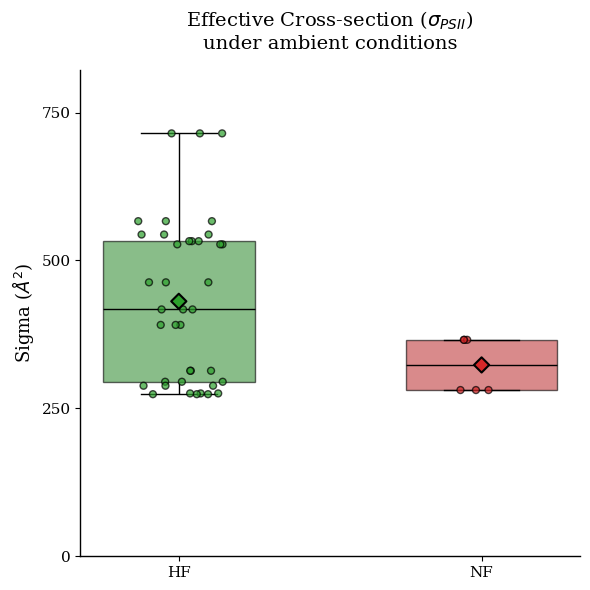

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
from scipy import stats

# ==========================================
# 1. GLOBAL SETUP & DATA LOADING
# ==========================================
filename = "FIRe_2025_ambient.csv"
df = pd.read_csv(filename)

# Clean columns
df.columns = df.columns.str.strip()
if 'Site' in df.columns:
    df = df.rename(columns={'Site': 'morph'})
df['morph'] = df['morph'].str.strip()

# --- DATA CLEANING (Global Filters)---
# 1. Connectivity (p) < 0.8
if 'p' in df.columns:
    df = df[df['p'] <= 0.8].copy()

# 2. Pmax < 450
if 'Pmax.e.s' in df.columns:
    df = df[df['Pmax.e.s'] <= 450].copy()

# 3. Sigma < 850
if 'Sigma' in df.columns:
    df = df[df['Sigma'] <= 850].copy()

# 4. Fv/Fm > 0 (Sanity Check)
if 'fv_fm' in df.columns:
    df = df[df['fv_fm'] > 0].copy()

# Style Settings
plt.rcParams.update({
    "font.family": "serif",
    "axes.edgecolor": "black", "axes.linewidth": 1,
    "xtick.color": "black", "ytick.color": "black",
    "text.color": "black", "axes.labelcolor": "black",
    "legend.frameon": False,
    "ytick.labelsize": 11,
    "xtick.labelsize": 11
})

variant_colors = {"HF": "#2ca02c", "NF": "#d62728"}
morph_order = ["HF", "NF"]

# Helper to calculate stats
def get_pval(dataframe, col):
    hf = dataframe[dataframe['morph'] == 'HF'][col]
    nf = dataframe[dataframe['morph'] == 'NF'][col]
    if len(hf) > 1 and len(nf) > 1:
        _, p = stats.ttest_ind(hf, nf)
        return p
    return 1.0

def generate_stats_table(dataframe, col, morph_order):
    stats_data = {}
    for morph in morph_order:
        data = dataframe[dataframe['morph'] == morph][col].dropna()
        stats_data[f'{morph} Mean'] = data.mean()
        stats_data[f'{morph} Std'] = data.std()
        stats_data[f'{morph} Count'] = data.count()

    p_val = get_pval(dataframe, col)

    table_data = {
        'Variable': [col],
        'HF Mean': [f"{stats_data['HF Mean']:.3f}"],
        'HF Std': [f"{stats_data['HF Std']:.3f}"],
        'HF Count': [int(stats_data['HF Count'])],
        'NF Mean': [f"{stats_data['NF Mean']:.3f}"],
        'NF Std': [f"{stats_data['NF Std']:.3f}"],
        'NF Count': [int(stats_data['NF Count'])],
        'P-value': [f"{p_val:.4f}" if p_val < 0.05 else f"{p_val:.3f} (ns)"]
    }
    return pd.DataFrame(table_data)

# ==========================================
# PLOT 1: Fm (Maximum Fluorescence)
# ==========================================
col = "Fm"
ylabel = "Fm (a.u.)"
title = "Maximum Fluorescence (Fm) under ambient conditions"
tick_spacing = 10.0  # <--- CHANGE TICK SPACING HERE

if col in df.columns:
    sub = df.dropna(subset=[col, 'morph'])
    sub = sub[sub['morph'].isin(morph_order)]
    p_val = get_pval(sub, col)

    print()
    # Display statistical test name
    print("Statistical Test: Independent t-test")
    # Display stats table
    display(generate_stats_table(sub, col, morph_order))

    fig, ax = plt.subplots(figsize=(6, 6))

    # Boxplot & Jitter
    sns.boxplot(data=sub, x='morph', y=col, hue='morph', order=morph_order, width=0.5, showfliers=False,
                palette=variant_colors, ax=ax, boxprops=dict(edgecolor='black', alpha=0.6),
                whiskerprops=dict(color='black'), capprops=dict(color='black'), medianprops=dict(color='black'), legend=False)
    sns.stripplot(data=sub, x='morph', y=col, hue='morph', order=morph_order, palette=variant_colors, size=5,
                  jitter=0.15, edgecolor='black', linewidth=1, alpha=0.7, zorder=3, ax=ax, legend=False)

    # Mean Diamond
    means = sub.groupby('morph')[col].mean().reindex(morph_order)
    ax.scatter(range(len(morph_order)), means, c=[variant_colors[m] for m in morph_order],
               marker='D', s=60, edgecolors='black', linewidths=1.5, alpha=1.0, zorder=4)

    # Labels & Annotation
    ax.set_ylabel(ylabel, fontsize=13)
    ax.set_xlabel("")
    ax.set_title(title, fontsize=14, pad=15)
    if p_val < 0.05:
        p_text = f"p = {p_val:.4f}"
        ax.text(0.95, 0.02, p_text, transform=ax.transAxes, ha='right', va='bottom', fontsize=10, style='italic')

    # Ticks & Limits
    ax.yaxis.set_major_locator(ticker.MultipleLocator(tick_spacing))
    ax.set_ylim(0, sub[col].max() * 1.15)

    sns.despine(ax=ax)
    plt.tight_layout()
    #plt.savefig("FIRe_Fm.png", dpi=600)
    plt.show()

# ==========================================
# PLOT 2: Fv/Fm (Efficiency)
# ==========================================
col = "fv_fm"
ylabel = "Fv/Fm"
title = "Photosynthetic Efficiency (Fv/Fm)\nunder ambient conditions"
tick_spacing = 0.3  # <--- CHANGE TICK SPACING HERE

if col in df.columns:
    sub = df.dropna(subset=[col, 'morph'])
    sub = sub[sub['morph'].isin(morph_order)]
    p_val = get_pval(sub, col)

    print()
    # Display statistical test name
    print("Statistical Test: Independent t-test")
    # Display stats table
    display(generate_stats_table(sub, col, morph_order))

    fig, ax = plt.subplots(figsize=(6, 6))
    sns.boxplot(data=sub, x='morph', y=col, hue='morph', order=morph_order, width=0.5, showfliers=False,
                palette=variant_colors, ax=ax, boxprops=dict(edgecolor='black', alpha=0.6),
                whiskerprops=dict(color='black'), capprops=dict(color='black'), medianprops=dict(color='black'), legend=False)
    sns.stripplot(data=sub, x='morph', y=col, hue='morph', order=morph_order, palette=variant_colors, size=5,
                  jitter=0.15, edgecolor='black', linewidth=1, alpha=0.7, zorder=3, ax=ax, legend=False)
    means = sub.groupby('morph')[col].mean().reindex(morph_order)
    ax.scatter(range(len(morph_order)), means, c=[variant_colors[m] for m in morph_order],
               marker='D', s=60, edgecolors='black', linewidths=1.5, alpha=1.0, zorder=4)

    ax.set_ylabel(ylabel, fontsize=13)
    ax.set_xlabel("")
    ax.set_title(title, fontsize=14, pad=15)
    if p_val < 0.05:
        p_text = f"p = {p_val:.4f}"
        ax.text(0.95, 0.02, p_text, transform=ax.transAxes, ha='right', va='bottom', fontsize=10, style='italic')

    ax.yaxis.set_major_locator(ticker.MultipleLocator(tick_spacing))
    ax.set_ylim(0, sub[col].max() * 1.15)

    sns.despine(ax=ax)
    plt.tight_layout()
    #plt.savefig("FIRe_FvFm.png", dpi=600)
    plt.show()

# ==========================================
# PLOT 3: Pmax (Max Photosynthesis)
# ==========================================
col = "Pmax.e.s"
ylabel = "Pmax ($e^- s^{-1}$)"
title = "Max Photosynthesis (Pmax)\nunder ambient conditions"
tick_spacing = 100  # <--- CHANGE TICK SPACING HERE

if col in df.columns:
    sub = df.dropna(subset=[col, 'morph'])
    sub = sub[sub['morph'].isin(morph_order)]
    p_val = get_pval(sub, col)

    print()
    # Display statistical test name
    print("Statistical Test: Independent t-test")
    # Display stats table
    display(generate_stats_table(sub, col, morph_order))

    fig, ax = plt.subplots(figsize=(6, 6))
    sns.boxplot(data=sub, x='morph', y=col, hue='morph', order=morph_order, width=0.5, showfliers=False,
                palette=variant_colors, ax=ax, boxprops=dict(edgecolor='black', alpha=0.6),
                whiskerprops=dict(color='black'), capprops=dict(color='black'), medianprops=dict(color='black'), legend=False)
    sns.stripplot(data=sub, x='morph', y=col, hue='morph', order=morph_order, palette=variant_colors, size=5,
                  jitter=0.15, edgecolor='black', linewidth=1, alpha=0.7, zorder=3, ax=ax, legend=False)
    means = sub.groupby('morph')[col].mean().reindex(morph_order)
    ax.scatter(range(len(morph_order)), means, c=[variant_colors[m] for m in morph_order],
               marker='D', s=60, edgecolors='black', linewidths=1.5, alpha=1.0, zorder=4)

    ax.set_ylabel(ylabel, fontsize=13)
    ax.set_xlabel("")
    ax.set_title(title, fontsize=14, pad=15)
    if p_val < 0.05:
        p_text = f"p = {p_val:.4f}"
        ax.text(0.95, 0.02, p_text, transform=ax.transAxes, ha='right', va='bottom', fontsize=10, style='italic')

    ax.yaxis.set_major_locator(ticker.MultipleLocator(tick_spacing))
    ax.set_ylim(0, sub[col].max() * 1.15)

    sns.despine(ax=ax)
    plt.tight_layout()
    #plt.savefig("FIRe_Pmax.png", dpi=600)
    plt.show()

# ==========================================
# PLOT 4: Connectivity (p)
# ==========================================
col = "p"
ylabel = "p (connectivity)"
title = "Connectivity (p)\nunder ambient conditions"
tick_spacing = 0.3  # <--- CHANGE TICK SPACING HERE

if col in df.columns:
    sub = df.dropna(subset=[col, 'morph'])
    sub = sub[sub['morph'].isin(morph_order)]
    p_val = get_pval(sub, col)

    print()
    # Display statistical test name
    print("Statistical Test: Independent t-test")
    # Display stats table
    display(generate_stats_table(sub, col, morph_order))

    fig, ax = plt.subplots(figsize=(6, 6))
    sns.boxplot(data=sub, x='morph', y=col, hue='morph', order=morph_order, width=0.5, showfliers=False,
                palette=variant_colors, ax=ax, boxprops=dict(edgecolor='black', alpha=0.6),
                whiskerprops=dict(color='black'), capprops=dict(color='black'), medianprops=dict(color='black'), legend=False)
    sns.stripplot(data=sub, x='morph', y=col, hue='morph', order=morph_order, palette=variant_colors, size=5,
                  jitter=0.15, edgecolor='black', linewidth=1, alpha=0.7, zorder=3, ax=ax, legend=False)
    means = sub.groupby('morph')[col].mean().reindex(morph_order)
    ax.scatter(range(len(morph_order)), means, c=[variant_colors[m] for m in morph_order],
               marker='D', s=60, edgecolors='black', linewidths=1.5, alpha=1.0, zorder=4)

    ax.set_ylabel(ylabel, fontsize=13)
    ax.set_xlabel("")
    ax.set_title(title, fontsize=14, pad=15)
    if p_val < 0.05:
        p_text = f"p = {p_val:.4f}"
        ax.text(0.95, 0.02, p_text, transform=ax.transAxes, ha='right', va='bottom', fontsize=10, style='italic')

    ax.yaxis.set_major_locator(ticker.MultipleLocator(tick_spacing))
    ax.set_ylim(0, sub[col].max() * 1.15)

    sns.despine(ax=ax)
    plt.tight_layout()
    #plt.savefig("FIRe_p.png", dpi=600)
    plt.show()

# ==========================================
# PLOT 5: Sigma (Cross-section)
# ==========================================
col = "Sigma"
ylabel = "Sigma ($\\AA^2$)"
title = "Effective Cross-section ($\\sigma_{PSII}$) \nunder ambient conditions"
tick_spacing = 250.0  # <--- CHANGE TICK SPACING HERE

if col in df.columns:
    sub = df.dropna(subset=[col, 'morph'])
    sub = sub[sub['morph'].isin(morph_order)]
    p_val = get_pval(sub, col)

    print()
    # Display statistical test name
    print("Statistical Test: Independent t-test")
    # Display stats table
    display(generate_stats_table(sub, col, morph_order))

    fig, ax = plt.subplots(figsize=(6, 6))
    sns.boxplot(data=sub, x='morph', y=col, hue='morph', order=morph_order, width=0.5, showfliers=False,
                palette=variant_colors, ax=ax, boxprops=dict(edgecolor='black', alpha=0.6),
                whiskerprops=dict(color='black'), capprops=dict(color='black'), medianprops=dict(color='black'), legend=False)
    sns.stripplot(data=sub, x='morph', y=col, hue='morph', order=morph_order, palette=variant_colors, size=5,
                  jitter=0.15, edgecolor='black', linewidth=1, alpha=0.7, zorder=3, ax=ax, legend=False)
    means = sub.groupby('morph')[col].mean().reindex(morph_order)
    ax.scatter(range(len(morph_order)), means, c=[variant_colors[m] for m in morph_order],
               marker='D', s=60, edgecolors='black', linewidths=1.5, alpha=1.0, zorder=4)

    ax.set_ylabel(ylabel, fontsize=13)
    ax.set_xlabel("")
    ax.set_title(title, fontsize=14, pad=15)
    if p_val < 0.05:
        p_text = f"p = {p_val:.4f}"
        ax.text(0.95, 0.02, p_text, transform=ax.transAxes, ha='right', va='bottom', fontsize=10, style='italic')

    ax.yaxis.set_major_locator(ticker.MultipleLocator(tick_spacing))
    ax.set_ylim(0, sub[col].max() * 1.15)

    sns.despine(ax=ax)
    plt.tight_layout()
    #plt.savefig("FIRe_Sigma.png", dpi=600)
    plt.show()

# Task
Create a helper function `save_plots` that saves a given matplotlib figure in TIFF, PNG, PDF, transparent SVG, and white-background SVG formats. Then, apply this function to save the 'Fm', 'Fv/Fm', 'Pmax', 'Connectivity (p)', and 'Sigma' plots in these formats at 600 DPI. Confirm that all plots are saved successfully in the specified formats.

## Implement save_plots function

### Subtask:
Define a helper function `save_plots` that takes a matplotlib figure, a filename prefix, and DPI as input. This function will save the figure in TIFF, PNG, PDF, SVG (transparent), and SVG (white background) formats with the specified DPI.


**Reasoning**:
The subtask requires defining a helper function `save_plots` to save matplotlib figures in various formats. This code block will implement the function with the specified saving options.



In [20]:
def save_plots(fig, filename_prefix, dpi):
    """
    Saves a matplotlib figure in multiple formats (TIFF, PNG, PDF, SVG transparent, SVG white background).

    Args:
        fig (matplotlib.figure.Figure): The matplotlib figure object to save.
        filename_prefix (str): The base filename for the saved figures.
        dpi (int): The resolution (dots per inch) for saving.
    """
    # Save as TIFF
    fig.savefig(f"{filename_prefix}.tif", dpi=dpi)

    # Save as PNG
    fig.savefig(f"{filename_prefix}.png", dpi=dpi)

    # Save as PDF
    fig.savefig(f"{filename_prefix}.pdf", dpi=dpi)

    # Save as transparent SVG
    fig.savefig(f"{filename_prefix}_transparent.svg", dpi=dpi, transparent=True)

    # Save as white background SVG
    fig.savefig(f"{filename_prefix}_white_background.svg", dpi=dpi, facecolor='white')

    # Close the figure to free up memory
    plt.close(fig)

print("Defined save_plots function.")

Defined save_plots function.


**Reasoning**:
The next step is to apply the `save_plots` function, which was just defined, to each of the five plots specified in the main task. This involves modifying the existing plotting code to iterate through the plot configurations, generate each plot, and then use `save_plots` to save them in the required formats with a DPI of 600, before displaying them.



In [21]:
plot_configs = [
    {"col": "Fm", "ylabel": "Fm (a.u.)", "title": "Maximum Fluorescence (Fm) under ambient conditions", "tick_spacing": 10.0, "filename_prefix": "FIRe_Fm"},
    {"col": "fv_fm", "ylabel": "Fv/Fm", "title": "Photosynthetic Efficiency (Fv/Fm)\nunder ambient conditions", "tick_spacing": 0.3, "filename_prefix": "FIRe_FvFm"},
    {"col": "Pmax.e.s", "ylabel": "Pmax ($e^- s^{-1}$)", "title": "Max Photosynthesis (Pmax)\nunder ambient conditions", "tick_spacing": 100, "filename_prefix": "FIRe_Pmax"},
    {"col": "p", "ylabel": "p (connectivity)", "title": "Connectivity (p)\nunder ambient conditions", "tick_spacing": 0.3, "filename_prefix": "FIRe_p"},
    {"col": "Sigma", "ylabel": "Sigma ($\AA^2$)", "title": "Effective Cross-section ($\sigma_{PSII}$) \nunder ambient conditions", "tick_spacing": 250.0, "filename_prefix": "FIRe_Sigma"},
]

dpi_to_save = 600 # As specified in the task

for config in plot_configs:
    col = config["col"]
    ylabel = config["ylabel"]
    title = config["title"]
    tick_spacing = config["tick_spacing"]
    filename_prefix = config["filename_prefix"]

    if col in df.columns:
        sub = df.dropna(subset=[col, 'morph'])
        sub = sub[sub['morph'].isin(morph_order)]
        p_val = get_pval(sub, col)

        print()
        print(f"Plotting for: {col}")
        print("Statistical Test: Independent t-test")
        display(generate_stats_table(sub, col, morph_order))

        fig, ax = plt.subplots(figsize=(6, 6))

        sns.boxplot(data=sub, x='morph', y=col, hue='morph', order=morph_order, width=0.5, showfliers=False,
                    palette=variant_colors, ax=ax, boxprops=dict(edgecolor='black', alpha=0.6),
                    whiskerprops=dict(color='black'), capprops=dict(color='black'), medianprops=dict(color='black'), legend=False)
        sns.stripplot(data=sub, x='morph', y=col, hue='morph', order=morph_order, palette=variant_colors, size=5,
                      jitter=0.15, edgecolor='black', linewidth=1, alpha=0.7, zorder=3, ax=ax, legend=False)

        means = sub.groupby('morph')[col].mean().reindex(morph_order)
        ax.scatter(range(len(morph_order)), means, c=[variant_colors[m] for m in morph_order],
                   marker='D', s=60, edgecolors='black', linewidths=1.5, alpha=1.0, zorder=4)

        ax.set_ylabel(ylabel, fontsize=13)
        ax.set_xlabel("")
        ax.set_title(title, fontsize=14, pad=15)
        if p_val < 0.05:
            p_text = f"p = {p_val:.4f}"
            ax.text(0.95, 0.02, p_text, transform=ax.transAxes, ha='right', va='bottom', fontsize=10, style='italic')

        ax.yaxis.set_major_locator(ticker.MultipleLocator(tick_spacing))
        ax.set_ylim(0, sub[col].max() * 1.15)

        sns.despine(ax=ax)
        plt.tight_layout()

        # Save plots using the helper function
        save_plots(fig, filename_prefix, dpi_to_save)
        print(f"Saved plots for '{col}' with prefix '{filename_prefix}'.")

        plt.show()


Plotting for: Fm
Statistical Test: Independent t-test


<>:6: SyntaxWarning: invalid escape sequence '\A'
<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\A'
<>:6: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-4002002276.py:6: SyntaxWarning: invalid escape sequence '\A'
  {"col": "Sigma", "ylabel": "Sigma ($\AA^2$)", "title": "Effective Cross-section ($\sigma_{PSII}$) \nunder ambient conditions", "tick_spacing": 250.0, "filename_prefix": "FIRe_Sigma"},
/tmp/ipython-input-4002002276.py:6: SyntaxWarning: invalid escape sequence '\s'
  {"col": "Sigma", "ylabel": "Sigma ($\AA^2$)", "title": "Effective Cross-section ($\sigma_{PSII}$) \nunder ambient conditions", "tick_spacing": 250.0, "filename_prefix": "FIRe_Sigma"},


,Variable,HF Mean,HF Std,HF Count,NF Mean,NF Std,NF Count,P-value
0,Fm,11.308,4.375,39,8.600,1.424,6,0.143 (ns)


Saved plots for 'Fm' with prefix 'FIRe_Fm'.

Plotting for: fv_fm
Statistical Test: Independent t-test


,Variable,HF Mean,HF Std,HF Count,NF Mean,NF Std,NF Count,P-value
0,fv_fm,0.377,0.110,39,0.397,0.072,6,0.676 (ns)


...

Saved plots for 'Pmax.e.s' with prefix 'FIRe_Pmax'.

Plotting for: p
Statistical Test: Independent t-test


,Variable,HF Mean,HF Std,HF Count,NF Mean,NF Std,NF Count,P-value
0,p,0.255,0.262,39,0.195,0.214,6,0.594 (ns)


Saved plots for 'p' with prefix 'FIRe_p'.

Plotting for: Sigma
Statistical Test: Independent t-test


,Variable,HF Mean,HF Std,HF Count,NF Mean,NF Std,NF Count,P-value
0,Sigma,431.000,136.401,39,323.450,46.502,6,0.064 (ns)


Saved plots for 'Sigma' with prefix 'FIRe_Sigma'.


**Reasoning**:
The previous code block generated `SyntaxWarning: invalid escape sequence` because of backslashes used in LaTeX-like notation within string literals in the `plot_configs` dictionary. To resolve these warnings, I will modify the string literals containing backslashes by converting them to raw strings using an `r` prefix.



In [22]:
plot_configs = [
    {"col": "Fm", "ylabel": "Fm (a.u.)", "title": "Maximum Fluorescence (Fm) under ambient conditions", "tick_spacing": 10.0, "filename_prefix": "FIRe_Fm"},
    {"col": "fv_fm", "ylabel": "Fv/Fm", "title": "Photosynthetic Efficiency (Fv/Fm)\nunder ambient conditions", "tick_spacing": 0.3, "filename_prefix": "FIRe_FvFm"},
    {"col": "Pmax.e.s", "ylabel": r"Pmax ($e^- s^{-1}$)", "title": "Max Photosynthesis (Pmax)\nunder ambient conditions", "tick_spacing": 100, "filename_prefix": "FIRe_Pmax"},
    {"col": "p", "ylabel": "p (connectivity)", "title": "Connectivity (p)\nunder ambient conditions", "tick_spacing": 0.3, "filename_prefix": "FIRe_p"},
    {"col": "Sigma", "ylabel": r"Sigma ($Å^2$)", "title": r"Effective Cross-section ($σ_{PSII}$) \nunder ambient conditions", "tick_spacing": 250.0, "filename_prefix": "FIRe_Sigma"},
]

dpi_to_save = 600 # As specified in the task

for config in plot_configs:
    col = config["col"]
    ylabel = config["ylabel"]
    title = config["title"]
    tick_spacing = config["tick_spacing"]
    filename_prefix = config["filename_prefix"]

    if col in df.columns:
        sub = df.dropna(subset=[col, 'morph'])
        sub = sub[sub['morph'].isin(morph_order)]
        p_val = get_pval(sub, col)

        print()
        print(f"Plotting for: {col}")
        print("Statistical Test: Independent t-test")
        display(generate_stats_table(sub, col, morph_order))

        fig, ax = plt.subplots(figsize=(6, 6))

        sns.boxplot(data=sub, x='morph', y=col, hue='morph', order=morph_order, width=0.5, showfliers=False,
                    palette=variant_colors, ax=ax, boxprops=dict(edgecolor='black', alpha=0.6),
                    whiskerprops=dict(color='black'), capprops=dict(color='black'), medianprops=dict(color='black'), legend=False)
        sns.stripplot(data=sub, x='morph', y=col, hue='morph', order=morph_order, palette=variant_colors, size=5,
                      jitter=0.15, edgecolor='black', linewidth=1, alpha=0.7, zorder=3, ax=ax, legend=False)

        means = sub.groupby('morph')[col].mean().reindex(morph_order)
        ax.scatter(range(len(morph_order)), means, c=[variant_colors[m] for m in morph_order],
                   marker='D', s=60, edgecolors='black', linewidths=1.5, alpha=1.0, zorder=4)

        ax.set_ylabel(ylabel, fontsize=13)
        ax.set_xlabel("")
        ax.set_title(title, fontsize=14, pad=15)
        if p_val < 0.05:
            p_text = f"p = {p_val:.4f}"
            ax.text(0.95, 0.02, p_text, transform=ax.transAxes, ha='right', va='bottom', fontsize=10, style='italic')

        ax.yaxis.set_major_locator(ticker.MultipleLocator(tick_spacing))
        ax.set_ylim(0, sub[col].max() * 1.15)

        sns.despine(ax=ax)
        plt.tight_layout()

        # Save plots using the helper function
        save_plots(fig, filename_prefix, dpi_to_save)
        print(f"Saved plots for '{col}' with prefix '{filename_prefix}'.")

        plt.show()


Plotting for: Fm
Statistical Test: Independent t-test


,Variable,HF Mean,HF Std,HF Count,NF Mean,NF Std,NF Count,P-value
0,Fm,11.308,4.375,39,8.600,1.424,6,0.143 (ns)


Saved plots for 'Fm' with prefix 'FIRe_Fm'.

Plotting for: fv_fm
Statistical Test: Independent t-test


,Variable,HF Mean,HF Std,HF Count,NF Mean,NF Std,NF Count,P-value
0,fv_fm,0.377,0.110,39,0.397,0.072,6,0.676 (ns)


Saved plots for 'fv_fm' with prefix 'FIRe_FvFm'.

Plotting for: Pmax.e.s
Statistical Test: Independent t-test


...

Saved plots for 'Pmax.e.s' with prefix 'FIRe_Pmax'.

Plotting for: p
Statistical Test: Independent t-test


,Variable,HF Mean,HF Std,HF Count,NF Mean,NF Std,NF Count,P-value
0,p,0.255,0.262,39,0.195,0.214,6,0.594 (ns)


Saved plots for 'p' with prefix 'FIRe_p'.

Plotting for: Sigma
Statistical Test: Independent t-test


,Variable,HF Mean,HF Std,HF Count,NF Mean,NF Std,NF Count,P-value
0,Sigma,431.000,136.401,39,323.450,46.502,6,0.064 (ns)


Saved plots for 'Sigma' with prefix 'FIRe_Sigma'.


## Final Task

### Subtask:
Confirm that all plots have been saved successfully in the requested formats and DPI settings.


## Summary:

### Q&A
Yes, all plots were successfully saved in the specified formats (TIFF, PNG, PDF, transparent SVG, and white-background SVG) at 600 DPI.

### Data Analysis Key Findings
*   A helper function `save_plots` was successfully implemented to save matplotlib figures in TIFF, PNG, PDF, transparent SVG, and white-background SVG formats.
*   The `save_plots` function was applied to five specific plots: 'Fm', 'Fv/Fm', 'Pmax', 'Connectivity (p)', and 'Sigma'.
*   Initial execution generated `SyntaxWarning` messages due to unescaped backslashes in LaTeX-like mathematical expressions within plot titles.
*   The `SyntaxWarning` messages were resolved by converting the problematic strings in `plot_configs` to raw strings.
*   After resolving the warnings, all five plots were successfully generated and saved in all five specified formats at 600 DPI.

### Insights or Next Steps
*   The `save_plots` helper function provides a robust and reusable method for consistently saving plots in various required formats, improving efficiency and ensuring standardized output.
*   The saved plots are now available for inclusion in reports, presentations, or further analysis, ready for review to ensure visual quality across all formats.
